# ThemeCloner V2 — revised point in time walk forward

This notebook keeps the existing data pull and RP PCA modules intact. The revised logic is isolated in three additive modules:

- `src/matching_v3.py`: robust multi ETF factor exposure matching
- `src/walkforward_v3.py`: point in time residualization, RP PCA fitting and basket formation
- `src/evaluation_v3.py`: forward exposure, placebo and semantic validation

The primary objective is to identify small cap stocks with related latent thematic exposures. Raw ETF return tracking is retained only as a secondary diagnostic.

In [1]:
# -------------------- 0. Setup --------------------
import os
import sys

ROOT = os.path.abspath(os.getcwd())
if not os.path.exists(os.path.join(ROOT, "config", "etfs.csv")):
    ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print(f"root: {ROOT}")
print(f"config exists: {os.path.exists('config/etfs.csv')}")

root: C:\Users\aamin\ThemeCloner2
config exists: True


## Step 1 — Pull the same raw inputs used by V2

In [2]:
# -------------------- 1a. Parameters and ETF config --------------------
from src.data_pull import load_etf_config, split_themes_controls

START_DATE = "2018-01-01"
K = 15
GAMMA = 10.0
TOP_N = 30
TOP_FACTORS = 5                      # retain more of each theme's factor shape

REBALANCE_FREQ = "Q"
WALKFORWARD_WINDOW = "rolling"      # "rolling" or "expanding"
ROLLING_WINDOW_WEEKS = 208          # four years
MIN_TRAIN_OBS = 104                 # at least two years of valid observations
MIN_TRAIN_COVERAGE = 0.80

INCLUDE_COMMODITY = False
N_PLACEBOS = 20                     # use 100 to 200 for final reported results
PLACEBO_PVALUE_MAX = 0.10           # rank matched null admission threshold
PLACEBO_USE_FDR = False             # q values are reported; p values gate admission
RANDOM_STATE = 42

# Process workers are used for placebo batches. Half the logical CPUs avoids
# oversubscription on mixed performance and efficiency core laptops.
N_JOBS = min(8, max(1, (os.cpu_count() or 4) // 2))
print(f"Placebo process workers: {N_JOBS}")

etf_config = load_etf_config("config/etfs.csv")
themes_config, controls_config = split_themes_controls(etf_config)
print(f"{themes_config['theme'].nunique()} discovery themes")


Placebo process workers: 8
loaded 44 ETFs: 31 theme-ETFs, 13 control-ETFs (sector/subsector calibration anchors)
  AI Infrastructure: IGPT (IGPT), QTUM (QTUM), SOXX (SOXX)
  Agribusiness: MOO (MOO), VEGI (VEGI), PBJ (PBJ)
  Clean Energy: ICLN (ICLN), QCLN (QCLN), PBW (PBW)
  Critical Minerals: URA (URA), LIT (LIT), COPX (COPX)
  Cybersecurity: CIBR (CIBR), HACK (HACK), BUG (BUG)
  Defense: ITA (ITA), PPA (PPA), XAR (XAR)
  Factor1: IUSG (IUSG)
  Factor2: VLUE (VLUE)
  Factor3: QUAL (QUAL)
  Factor4: SPGP (SPGP)
  Factor5: MTUM (MTUM)
  Factor6: VUG (VUG)
  Factor7: VTV (VTV)
  Fintech: FINX (FINX), ARKF (ARKF), IPAY (IPAY)
  Robotics & AI: BOTZ (BOTZ), ROBO (ROBO), IRBO (IRBO)
  SECTOR: US Energy: XLE (XLE)
  SECTOR: US Financials: XLF (XLF)
  SECTOR: US Technology: XLK (XLK)
  SUBSECTOR: US Banks: KRE (KRE)
  SUBSECTOR: US Biotech: XBI (XBI)
  SUBSECTOR: US Software: IGV (IGV)
  Timber & Forestry: WOOD (WOOD), CUT (CUT)
  US Infrastructure: PAVE (PAVE), IFRA (IFRA)
  Water: PHO (PHO),

In [3]:
# -------------------- 1b. ETF returns --------------------
from src.data_pull import pull_etf_returns

etf_returns = pull_etf_returns(etf_config, start=START_DATE)
print(etf_returns.shape)


pulling ETF panel: 44 tickers in 1 batch(es)
  batch 1/1 (44 tickers)...
  dropped 1 tickers below 85% coverage
  ETF panel: 445 weeks x 43 stocks
  date range: 2018-01-12 to 2026-07-17
  ETFs kept: ['ARKF', 'BOTZ', 'CGW', 'CIBR', 'COPX', 'CUT', 'FINX', 'FIW', 'HACK', 'ICLN', 'IFRA', 'IGPT', 'IGV', 'IPAY', 'IRBO', 'ITA', 'IUSG', 'KRE', 'LIT', 'MOO', 'MTUM', 'PAVE', 'PBJ', 'PBW', 'PHO', 'PPA', 'QCLN', 'QTUM', 'QUAL', 'ROBO', 'SOXX', 'SPGP', 'URA', 'VEGI', 'VLUE', 'VTV', 'VUG', 'WOOD', 'XAR', 'XBI', 'XLE', 'XLF', 'XLK']
(445, 43)


In [4]:
# -------------------- 1c. Covariance universe --------------------
from src.data_pull import pull_covariance_universe

cov_returns = pull_covariance_universe(
    start=START_DATE,
    use_cache=True,
    us_only=True,
)
print(cov_returns.shape)

loaded covariance universe from cache (us_only): 1003 tickers across ['us_sp500', 'us_mid_small']

pulling covariance universe: 1003 unique tickers

pulling covariance universe: 1003 tickers in 3 batch(es)
  batch 1/3 (400 tickers)...
  batch 2/3 (400 tickers)...


$BAYA: possibly delisted; no price data found  (1d 2018-01-01 -> 2026-07-18)

1 Failed download:
['BAYA']: possibly delisted; no price data found  (1d 2018-01-01 -> 2026-07-18)


  batch 3/3 (203 tickers)...


$TBH: possibly delisted; no price data found  (1d 2018-01-01 -> 2026-07-18)

1 Failed download:
['TBH']: possibly delisted; no price data found  (1d 2018-01-01 -> 2026-07-18)


  dropped 251 tickers below 85% coverage
  covariance universe: 445 weeks x 752 stocks
  date range: 2018-01-12 to 2026-07-17
(445, 752)


In [5]:
# -------------------- 1d. Target universe --------------------
from src.data_pull import _cached_returns, pull_target_universe

tgt_returns = _cached_returns(
    "target_universe_returns",
    pull_target_universe,
    refresh=False,
    start=START_DATE,
)
print(tgt_returns.shape)

  loaded target_universe_returns from cache: 444 weeks x 811 cols
(444, 811)


In [6]:
# -------------------- 1e. Observable factor returns --------------------
# IMPORTANT: do not residualize the full sample here.
# The revised walk forward module fits residualization inside each rebalance window.
from src.residualize import get_combined_factors

ff_factors = get_combined_factors(
    start=START_DATE,
    include_commodity=INCLUDE_COMMODITY,
)
print(ff_factors.shape)


pulling FF5 + momentum from Kenneth French library (weekly)...
  momentum fetch failed via pandas_datareader (Unknown datetime string format, unable to parse: Missing data are indicated by -99.99 or -999., at position 0)
  falling back to direct download from Ken French's data library...
  first 20 raw lines (for diagnosis):
    'This file was created by using the 202605 CRSP database.  It,,'
    'contains a momentum factor, constructed from six value-weight portfolios formed,'
    'using independent sorts on size and prior return of NYSE, AMEX, and NASDAQ stocks.'
    'MOM is the average of the returns on two (big and small) high prior return portfolios,,'
    'minus the average of the returns on two low prior return portfolios.  The portfolios,,'
    'are constructed daily.  Big means a firm is above the median market cap on the NYSE,,'
    'at the end of the previous day; small firms are below the median NYSE market cap.,,'
    'Prior return is measured from day - 250 to - 21.  Fir

## Step 2 — Build the point in time rebalance schedule

In [7]:
# -------------------- 2. Rebalance dates --------------------
from src.rppca_walkforward import make_rebalance_dates

# Restrict the schedule to dates where the observable factor panel is available.
model_dates = cov_returns.index.intersection(ff_factors.index)
minimum_window = ROLLING_WINDOW_WEEKS if WALKFORWARD_WINDOW == "rolling" else MIN_TRAIN_OBS

rebalance_dates = make_rebalance_dates(
    model_dates,
    freq=REBALANCE_FREQ,
    min_window_weeks=minimum_window,
)
print(f"{len(rebalance_dates)} rebalance dates")
print(rebalance_dates[:3], "...", rebalance_dates[-3:])

18 rebalance dates
[Timestamp('2021-12-31 00:00:00'), Timestamp('2022-03-25 00:00:00'), Timestamp('2022-06-24 00:00:00')] ... [Timestamp('2025-09-26 00:00:00'), Timestamp('2025-12-26 00:00:00'), Timestamp('2026-03-27 00:00:00')]


## Step 3 — Matching rules

In [8]:
# -------------------- 3. Robust matching configuration --------------------
from src.matching_v3 import MatchingConfig

matching_config = MatchingConfig(
    top_factors=TOP_FACTORS,

    # Confidence filters use both raw and adjusted R squared.
    min_etf_r2=0.10,
    min_etf_adjusted_r2=0.05,
    min_candidate_r2=0.15,
    min_candidate_adjusted_r2=0.10,

    # Consensus checks across the theme ETF reference set.
    min_cosine=0.30,
    cosine_quantile=0.25,            # lower quartile cosine must clear the floor
    reference_distance_quantile=0.75,# poor ETF match cannot be averaged away

    max_relative_distance=None,
    factor_gap_weight=0.25,
    consensus_weight=0.25,

    min_etf_matches=1,
    min_etf_match_fraction=0.60,     # 2 of 2 ETFs; at least 2 of 3 ETFs
    etf_match_distance=None,

    # Overlap is diagnosed, not prohibited.
    max_theme_rank=None,
)
matching_config


MatchingConfig(top_factors=5, min_etf_r2=0.1, min_etf_adjusted_r2=0.05, min_candidate_r2=0.15, min_candidate_adjusted_r2=0.1, min_cosine=0.3, cosine_quantile=0.25, reference_distance_quantile=0.75, max_relative_distance=None, factor_gap_weight=0.25, consensus_weight=0.25, min_etf_matches=1, min_etf_match_fraction=0.6, etf_match_distance=None, max_theme_rank=None)

## Step 4 — Run the revised walk forward process

### 3B. Parallel execution

Ticker regressions are vectorized. Independent placebo batches use separate process workers, so the earlier Windows `threadpoolctl` workaround is no longer required.


In [9]:
# -------------------- 4. Point in time backtest --------------------
from src.walkforward_v3 import run_point_in_time_backtest

results = run_point_in_time_backtest(
    cov_returns_raw=cov_returns,
    etf_returns_raw=etf_returns,
    target_returns_raw=tgt_returns,
    factor_returns=ff_factors,
    etf_config=themes_config,
    rebalance_dates=rebalance_dates,
    K=K,
    gamma=GAMMA,
    window=WALKFORWARD_WINDOW,
    rolling_window_weeks=ROLLING_WINDOW_WEEKS,
    top_n=TOP_N,
    matching_config=matching_config,
    min_train_obs=MIN_TRAIN_OBS,
    min_train_coverage=MIN_TRAIN_COVERAGE,
    n_placebos=N_PLACEBOS,
    placebo_pvalue_max=PLACEBO_PVALUE_MAX,
    placebo_use_fdr=PLACEBO_USE_FDR,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    verbose=True,
)



Rebalance 1/18: 2021-12-31
RP-PCA fitted: K=15, gamma=10.0
  in-sample SR:      7.050
  top eigenvalues:   [61.8 41.7 25.2 21.2 17.4 16.7 14.9 13.  12.5 11.4 10.2  9.4  9.2  8.8
  8.7]
Selected 172 positions across 11 themes; forward window has 12 observations.
Timing seconds: residualization=0.1, rppca=0.9, reference_and_candidate_fit=3.9, placebos_and_admission=28.5, forward_evaluation=5.2, placebo_forward_metrics=0.5, total=39.2

Rebalance 2/18: 2022-03-25
RP-PCA fitted: K=15, gamma=10.0
  in-sample SR:      6.540
  top eigenvalues:   [63.7 40.5 25.4 22.6 18.3 16.3 14.8 13.5 12.5 11.4 10.4  9.6  9.   9.
  8.7]
Selected 192 positions across 11 themes; forward window has 13 observations.
Timing seconds: residualization=0.2, rppca=1.0, reference_and_candidate_fit=4.0, placebos_and_admission=16.8, forward_evaluation=0.6, placebo_forward_metrics=0.4, total=23.1

Rebalance 3/18: 2022-06-24
RP-PCA fitted: K=15, gamma=10.0
  in-sample SR:      6.446
  top eigenvalues:   [62.8 35.6 26.3 22.

RP-PCA fitted: K=15, gamma=10.0
  in-sample SR:      7.649
  top eigenvalues:   [62.4 49.5 26.4 20.6 19.7 15.5 14.8 13.7 11.5 11.1 10.2  9.5  9.3  9.2
  8.8]
Selected 128 positions across 11 themes; forward window has 13 observations.
Timing seconds: residualization=0.1, rppca=0.7, reference_and_candidate_fit=4.0, placebos_and_admission=17.2, forward_evaluation=0.6, placebo_forward_metrics=0.4, total=23.0

Rebalance 16/18: 2025-09-26
RP-PCA fitted: K=15, gamma=10.0
  in-sample SR:      7.023
  top eigenvalues:   [64.7 47.5 26.  20.3 19.  16.6 14.1 13.8 11.6 11.3 10.2  9.7  9.3  8.9
  8.7]
Selected 135 positions across 11 themes; forward window has 13 observations.
Timing seconds: residualization=0.1, rppca=0.7, reference_and_candidate_fit=5.1, placebos_and_admission=16.1, forward_evaluation=0.6, placebo_forward_metrics=0.3, total=22.9

Rebalance 17/18: 2025-12-26
RP-PCA fitted: K=15, gamma=10.0
  in-sample SR:      7.298
  top eigenvalues:   [68.1 46.  26.6 20.3 18.8 16.9 14.3 12.7 12.

## Step 5 — Review the latest selected baskets

In [10]:
# -------------------- 5a. Latest baskets --------------------
from src.matching_v3 import flatten_baskets

basket_history = flatten_baskets(results["period_baskets"])

if basket_history.empty:
    print(
        "No stocks passed the current matching thresholds in any rebalance period."
    )

    # Show how many names passed in each period and theme.
    selection_counts = pd.DataFrame(
        [
            {
                "rebalance_date": date,
                "theme": theme,
                "n_selected": len(basket.get("tickers", [])),
            }
            for date, theme_map in results["period_baskets"].items()
            for theme, basket in theme_map.items()
        ]
    )

    display(selection_counts)
else:
    latest_date = basket_history["rebalance_date"].max()
    latest_baskets = basket_history.loc[
        basket_history["rebalance_date"] == latest_date
    ]

    print(f"Latest rebalance: {latest_date.date()}")
    display(
        latest_baskets.sort_values(["theme", "ticker"])
    )

Latest rebalance: 2026-03-27


,rebalance_date,theme,ticker,weight
2733,2026-03-27,AI Infrastructure,NVEC,0.333333
2734,2026-03-27,AI Infrastructure,PAMT,0.333333
2732,2026-03-27,AI Infrastructure,PFX,0.333333
2737,2026-03-27,Agribusiness,ACNT,0.100000
2739,2026-03-27,Agribusiness,ASA,0.100000
...,...,...,...,...
2881,2026-03-27,US Infrastructure,MTUS,0.333333
2883,2026-03-27,US Infrastructure,NGVC,0.333333
2882,2026-03-27,US Infrastructure,SXC,0.333333
2885,2026-03-27,Water,GWRS,0.500000


In [11]:
# -------------------- 5c. Rebuild baskets without placebo admission --------------------
from src.matching_v3 import select_equal_weight_baskets, flatten_baskets

period_baskets_base = {}

for date, scores in results["period_scores"].items():
    revised_scores = scores.copy()
    revised_scores["eligible"] = revised_scores["base_eligible"]

    period_baskets_base[date] = select_equal_weight_baskets(
        revised_scores,
        top_n=TOP_N,
    )

basket_history_base = flatten_baskets(period_baskets_base)

latest_date = basket_history_base["rebalance_date"].max()
latest_baskets_base = basket_history_base.loc[
    basket_history_base["rebalance_date"] == latest_date
]

print(f"Latest rebalance: {latest_date.date()}")
print(f"Selected positions: {len(latest_baskets_base)}")
print(f"Unique stocks: {latest_baskets_base['ticker'].nunique()}")

display(
    latest_baskets_base.sort_values(["theme", "ticker"])
)

Latest rebalance: 2026-03-27
Selected positions: 154
Unique stocks: 99


,rebalance_date,theme,ticker,weight
2733,2026-03-27,AI Infrastructure,NVEC,0.333333
2734,2026-03-27,AI Infrastructure,PAMT,0.333333
2732,2026-03-27,AI Infrastructure,PFX,0.333333
2737,2026-03-27,Agribusiness,ACNT,0.100000
2739,2026-03-27,Agribusiness,ASA,0.100000
...,...,...,...,...
2881,2026-03-27,US Infrastructure,MTUS,0.333333
2883,2026-03-27,US Infrastructure,NGVC,0.333333
2882,2026-03-27,US Infrastructure,SXC,0.333333
2885,2026-03-27,Water,GWRS,0.500000


In [12]:
# -------------------- 5b. Latest detailed scores --------------------

latest_scores = results["period_scores"][latest_date]

latest_scores.loc[
    latest_scores["base_eligible"]
].sort_values(
    ["theme", "penalized_distance"]
).groupby(
    "theme",
    sort=False,
).head(10)[
    [
        "theme",
        "ticker",
        "penalized_distance",
        "consensus_cosine",
        "candidate_r2",
        "candidate_adjusted_r2",
        "n_etf_matches",
        "required_etf_matches",
        "placebo_rank_pvalue",
        "theme_distance_rank",
        "n_eligible_themes",
    ]
]

,theme,ticker,penalized_distance,consensus_cosine,candidate_r2,candidate_adjusted_r2,n_etf_matches,required_etf_matches,placebo_rank_pvalue,theme_distance_rank,n_eligible_themes
0,AI Infrastructure,PFX,1.775172,0.350626,0.167835,0.102822,3,2,0.500000,9.0,5
1,AI Infrastructure,NVEC,1.925458,0.470959,0.172289,0.107624,3,2,0.500000,3.0,3
2,AI Infrastructure,PAMT,2.733573,0.305539,0.184308,0.120582,2,2,0.500000,4.0,1
811,Agribusiness,PFX,1.342059,0.385211,0.167835,0.102822,3,2,0.142857,2.0,5
812,Agribusiness,HRZN,1.962727,0.300122,0.166419,0.101296,2,2,0.142857,5.0,2
...,...,...,...,...,...,...,...,...,...,...,...
7299,US Infrastructure,MTUS,2.373343,0.371089,0.195500,0.132648,2,2,0.200000,6.0,4
7300,US Infrastructure,SXC,2.630697,0.401059,0.256507,0.198422,2,2,0.200000,5.0,3
7301,US Infrastructure,NGVC,3.116398,0.309654,0.220963,0.160100,2,2,0.400000,3.0,1
8110,Water,PFX,1.487137,0.418874,0.167835,0.102822,3,2,0.166667,4.0,5


In [13]:
# -------------------- 5c. Selection overlap diagnostic --------------------

theme_counts = (
    latest_baskets_base.groupby("theme")
    .agg(
        n_selected=("ticker", "size"),
        n_unique=("ticker", "nunique"),
    )
    .sort_values("n_selected")
)

ticker_overlap = (
    latest_baskets_base.groupby("ticker")
    .agg(
        n_themes=("theme", "nunique"),
        themes=("theme", lambda x: ", ".join(sorted(set(x)))),
    )
    .query("n_themes > 1")
    .sort_values(["n_themes", "ticker"], ascending=[False, True])
)

display(theme_counts)
display(ticker_overlap.head(30))

,n_selected,n_unique
theme,,
Water,2,2
AI Infrastructure,3,3
US Infrastructure,3,3
Agribusiness,10,10
Defense,10,10
Fintech,12,12
Clean Energy,13,13
Robotics & AI,17,17
Critical Minerals,27,27


,n_themes,themes
ticker,,
GOOS,5,"Agribusiness, Clean Energy, Critical Minerals,..."
PFX,5,"AI Infrastructure, Agribusiness, Defense, Robo..."
ASA,4,"Agribusiness, Critical Minerals, Defense, Timb..."
MTUS,4,"Agribusiness, Critical Minerals, Timber & Fore..."
CSIQ,3,"Clean Energy, Critical Minerals, Robotics & AI"
ELME,3,"Cybersecurity, Fintech, Timber & Forestry"
GSM,3,"Agribusiness, Critical Minerals, Timber & Fore..."
JKS,3,"Clean Energy, Critical Minerals, Robotics & AI"
LGO,3,"Critical Minerals, Defense, Timber & Forestry"


In [14]:
# -------------------- 5d. Are the theme reference sets distinct? --------------------
latest_reference_distances = results["theme_reference_distances"]
latest_reference_distances = latest_reference_distances.loc[
    latest_reference_distances["rebalance_date"] == latest_date
]
latest_reference_distances.sort_values(
    ["median_relative_distance", "maximum_cosine"],
    ascending=[True, False],
).head(30)


,rebalance_date,theme_1,theme_2,median_relative_distance,minimum_relative_distance,maximum_cosine,median_cosine
982,2026-03-27,US Infrastructure,Water,0.794209,0.548401,0.721246,0.501961
959,2026-03-27,Clean Energy,Critical Minerals,0.845851,0.671333,0.648792,0.485091
935,2026-03-27,Robotics & AI,AI Infrastructure,0.894309,0.703613,0.715711,0.626236
945,2026-03-27,AI Infrastructure,Clean Energy,0.912351,0.771661,0.545226,0.431989
983,2026-03-27,US Infrastructure,Timber & Forestry,0.918566,0.616907,0.562510,0.421929
989,2026-03-27,Water,Timber & Forestry,0.947482,0.840973,0.300506,0.252005
988,2026-03-27,Critical Minerals,Timber & Forestry,0.977561,0.715519,0.733075,0.679096
970,2026-03-27,Defense,US Infrastructure,0.986976,0.909945,0.510208,0.396065
985,2026-03-27,Agribusiness,Water,0.998772,0.825634,0.429597,0.180586
986,2026-03-27,Agribusiness,Timber & Forestry,1.019677,0.792668,0.641059,0.462262


In [15]:
# -------------------- 5e. Runtime bottleneck diagnostic --------------------
results["timings"].sort_values("rebalance_date")


,rebalance_date,residualization,rppca,reference_and_candidate_fit,placebos_and_admission,forward_evaluation,placebo_forward_metrics,total
0,2021-12-31,0.132425,0.930959,3.911920,28.496279,5.193671,0.548475,39.213740
1,2022-03-25,0.167267,1.044256,4.047495,16.847035,0.604660,0.403718,23.114443
2,2022-06-24,0.137826,0.903740,4.032465,13.323390,0.868357,0.407993,19.673782
3,2022-09-30,0.142641,1.054486,4.267373,19.257055,0.592919,0.357451,25.671939
4,2022-12-30,0.148423,1.002472,4.166365,12.327133,0.762120,0.424781,18.831308
5,2023-03-31,0.234650,0.829136,4.098324,17.227828,0.972304,0.737997,24.100258
6,2023-06-30,0.190200,0.727891,4.458410,34.340407,1.121655,0.825321,41.663902
7,2023-09-29,0.181345,0.781419,4.052976,17.387409,0.587010,0.452130,23.442301
8,2023-12-29,0.142739,0.677322,4.087269,15.136029,0.598392,0.393101,21.034866
9,2024-03-29,0.134618,0.728534,4.246730,17.722204,0.762094,0.453160,24.047355


## Step 6 — Forward exposure evaluation

In [16]:
# -------------------- 6a. Theme level summary --------------------
from src.evaluation_v3 import summarize_forward_evaluation

evaluation_summary = summarize_forward_evaluation(results["evaluation"])
evaluation_summary.sort_values("median_rank_ic", ascending=False)

,theme,periods,median_rank_ic,mean_rank_ic,median_top_bottom_spread,median_selected_forward_corr,median_basket_etf_corr,median_exposure_hit_rate,median_placebo_pvalue,rank_ic_positive_rate
3,Cybersecurity,18,0.240073,0.172494,0.149501,0.080655,0.233510,0.638095,0.500000,0.777778
9,Water,18,0.167857,-0.005476,0.100369,0.106709,0.104884,0.541667,0.500000,0.625000
2,Clean Energy,18,0.091955,0.048570,0.106305,0.117454,0.221549,0.666667,0.500000,0.555556
10,Timber & Forestry,18,0.075375,0.077644,0.023133,0.083405,-0.002449,0.629167,0.500000,0.611111
4,Defense,18,0.044012,0.040944,0.023653,0.116538,0.167679,0.641429,0.500000,0.666667
0,Robotics & AI,18,0.000000,0.017013,-0.024514,0.092445,0.236250,0.633971,0.500000,0.466667
5,Fintech,17,-0.050062,0.030945,0.011346,0.143368,0.094293,0.633333,0.333333,0.437500
1,AI Infrastructure,18,-0.100000,-0.044848,-0.155594,0.102704,0.220794,0.633333,0.500000,0.400000
8,Critical Minerals,18,-0.155606,-0.126292,-0.105581,0.234131,0.430452,0.811404,0.250000,0.388889
6,US Infrastructure,17,-0.214286,-0.108903,-0.243115,0.108082,0.222422,0.700000,0.500000,0.285714


In [17]:
# -------------------- 6b. Period level metrics --------------------
# Primary metrics:
# 1. forward_rank_ic_corr
# 2. top_bottom_corr_spread
# 3. basket_residual_etf_corr
# 4. placebo_pvalue
results["evaluation"].sort_values(["theme", "rebalance_date"])

,rebalance_date,theme,n_selected,n_base_eligible,forward_rank_ic_beta,forward_rank_ic_corr,top_bottom_beta_spread,top_bottom_corr_spread,selected_mean_forward_beta,selected_mean_forward_corr,exposure_hit_rate,basket_synthetic_beta,basket_synthetic_corr,basket_residual_etf_beta,basket_residual_etf_corr,raw_basket_period_return,raw_etf_blend_period_return,n_benchmark_etfs,placebo_pvalue,placebo_median_basket_corr
1,2021-12-31,AI Infrastructure,9,9,-0.366667,-0.300000,NaN,NaN,2.384541,0.249442,0.666667,2.384541,0.724586,0.284656,0.228170,-0.011663,-0.118814,3,0.166667,-0.167154
12,2022-03-25,AI Infrastructure,10,10,-0.115152,0.054545,-0.842435,-0.076495,1.739782,0.166368,0.800000,1.739782,0.389620,0.907982,0.442237,-0.065729,-0.181635,3,0.250000,-0.234770
23,2022-06-24,AI Infrastructure,5,5,-0.200000,-0.100000,NaN,NaN,0.099996,0.021421,0.600000,0.099996,0.029759,0.514869,0.333783,-0.120948,-0.134088,3,0.750000,0.095128
34,2022-09-30,AI Infrastructure,4,4,NaN,NaN,NaN,NaN,0.576587,0.074880,0.500000,0.576587,0.122727,0.477441,0.213419,0.152731,0.058432,3,0.333333,-0.349819
45,2022-12-30,AI Infrastructure,1,1,NaN,NaN,NaN,NaN,5.306819,0.385023,1.000000,5.306819,0.385023,3.181498,0.253122,-0.045901,0.185542,3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,2025-03-28,Water,2,2,NaN,NaN,NaN,NaN,-0.000446,0.106623,0.500000,-0.000446,-0.000137,0.425812,0.169106,-0.100036,0.089680,3,0.800000,0.235234
161,2025-06-27,Water,4,4,NaN,NaN,NaN,NaN,-0.391868,-0.086086,0.250000,-0.391868,-0.122561,-0.444322,-0.271539,-0.090320,0.021562,3,0.500000,-0.166372
172,2025-09-26,Water,2,2,NaN,NaN,NaN,NaN,1.059249,0.212862,1.000000,1.059249,0.284519,0.778477,0.452214,-0.077391,0.006802,3,0.333333,-0.165442
183,2025-12-26,Water,4,4,NaN,NaN,NaN,NaN,1.366328,0.430560,1.000000,1.366328,0.746009,0.682330,0.397356,-0.013759,-0.066386,3,0.500000,-0.347524


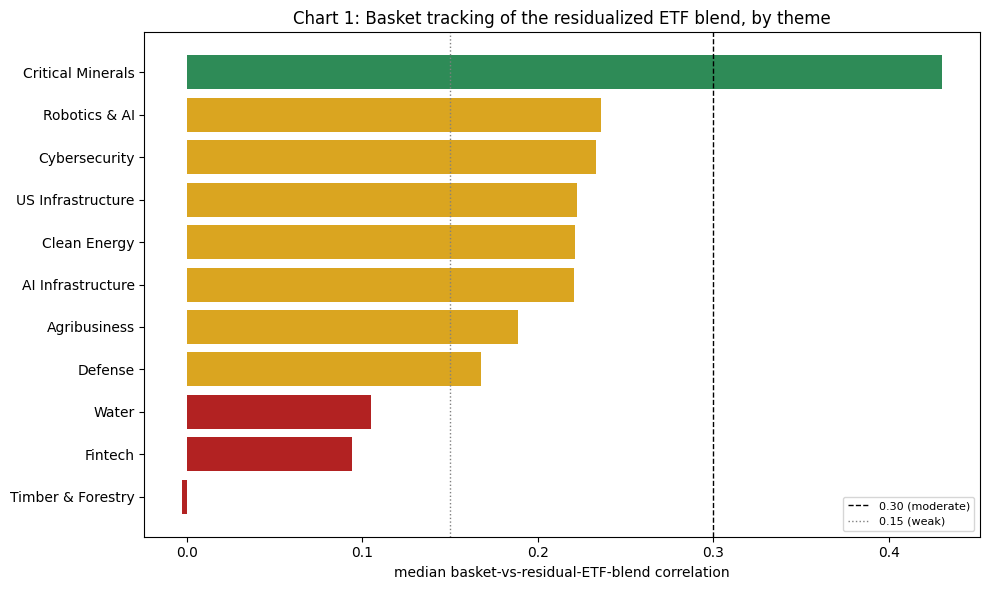

In [18]:
# -------------------- Chart 1. Median residual ETF correlation by theme --------------------
import matplotlib.pyplot as plt

chart1 = evaluation_summary.sort_values("median_basket_etf_corr", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["seagreen" if v >= 0.30 else "goldenrod" if v >= 0.15 else "firebrick"
          for v in chart1["median_basket_etf_corr"]]
ax.barh(chart1["theme"], chart1["median_basket_etf_corr"], color=colors)
ax.axvline(0.30, color="black", linestyle="--", linewidth=1, label="0.30 (moderate)")
ax.axvline(0.15, color="gray", linestyle=":", linewidth=1, label="0.15 (weak)")
ax.set_xlabel("median basket-vs-residual-ETF-blend correlation")
ax.set_title("Chart 1: Basket tracking of the residualized ETF blend, by theme")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("outputs/fig_v3_chart1_median_etf_corr.png", dpi=150)
plt.show()

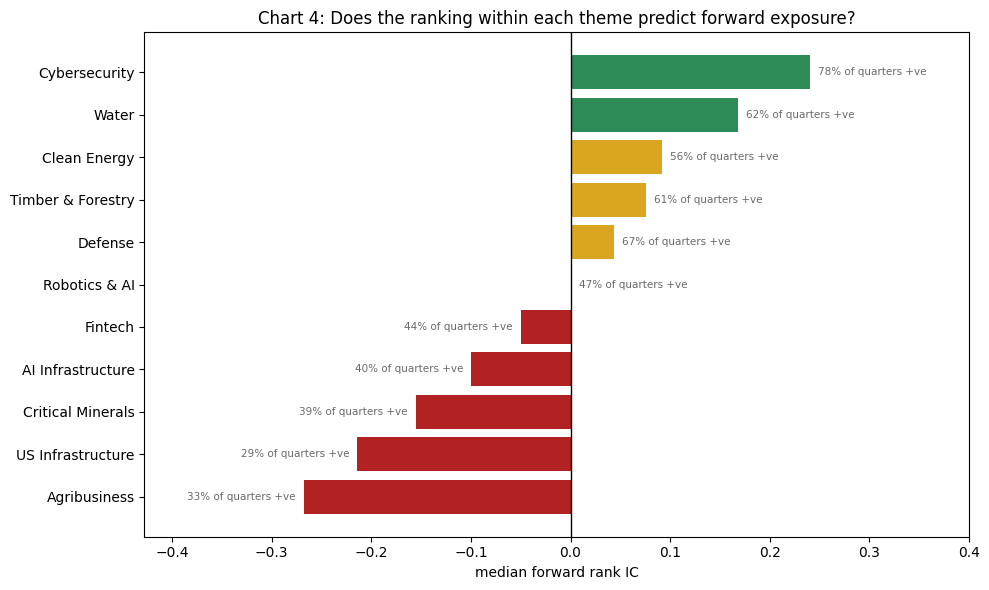

In [27]:
# -------------------- Chart 4. Median forward rank IC by theme --------------------
# This is the ranking metric, distinct from Chart 1's basket-level tracking.
# Positive means the model's ordering of stocks within a theme predicts which
# ones have stronger forward thematic exposure. Negative means the ordering is
# worse than no ordering at all.
import matplotlib.pyplot as plt

chart4 = evaluation_summary.sort_values("median_rank_ic", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["seagreen" if v >= 0.10 else "goldenrod" if v > 0 else "firebrick"
          for v in chart4["median_rank_ic"]]
bars = ax.barh(chart4["theme"], chart4["median_rank_ic"], color=colors)
ax.axvline(0, color="black", linewidth=1)

# label each bar with how often the rank IC was positive, quarter to quarter
for bar, rate in zip(bars, chart4["rank_ic_positive_rate"]):
    width = bar.get_width()
    offset = 0.008 if width >= 0 else -0.008
    ax.text(width + offset, bar.get_y() + bar.get_height() / 2,
            f"{rate:.0%} of quarters +ve",
            va="center", ha="left" if width >= 0 else "right", fontsize=7.5,
            color="dimgray")

ax.set_xlim(chart4["median_rank_ic"].min() - 0.16,
            chart4["median_rank_ic"].max() + 0.16)
ax.set_xlabel("median forward rank IC")
ax.set_title("Chart 4: Does the ranking within each theme predict forward exposure?")
plt.tight_layout()
plt.savefig("outputs/fig_v3_chart4_median_rank_ic.png", dpi=150)
plt.show()

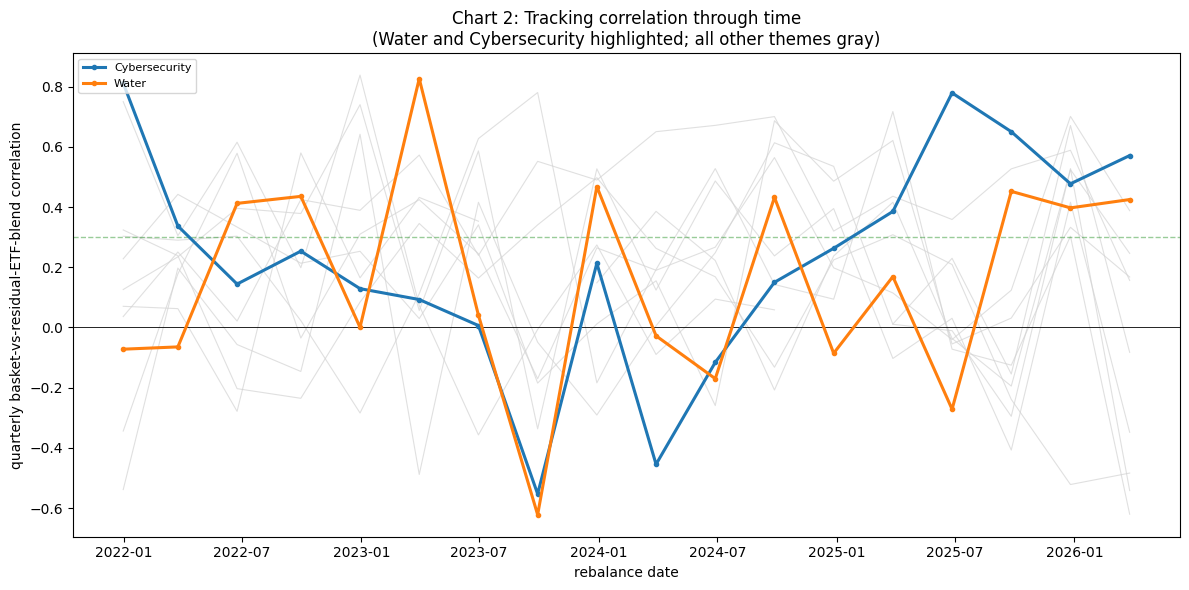

In [19]:
# -------------------- Chart 2. Quarterly tracking correlation through time --------------------
import matplotlib.pyplot as plt

ev = results["evaluation"]
pivot2 = ev.pivot_table(index="rebalance_date",
                         columns="theme",
                         values="basket_residual_etf_corr")

fig, ax = plt.subplots(figsize=(12, 6))
highlight = ["Water", "Cybersecurity"]
for theme in pivot2.columns:
    if theme in highlight:
        ax.plot(pivot2.index, pivot2[theme], linewidth=2.2, marker="o",
                markersize=3, label=theme, zorder=3)
    else:
        ax.plot(pivot2.index, pivot2[theme], linewidth=0.8, color="lightgray",
                alpha=0.7, zorder=1)
ax.axhline(0, color="black", linewidth=0.6)
ax.axhline(0.30, color="green", linestyle="--", alpha=0.4, linewidth=1)
ax.set_ylabel("quarterly basket-vs-residual-ETF-blend correlation")
ax.set_xlabel("rebalance date")
ax.set_title("Chart 2: Tracking correlation through time\n"
             "(Water and Cybersecurity highlighted; all other themes gray)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("outputs/fig_v3_chart2_tracking_through_time.png", dpi=150)
plt.show()

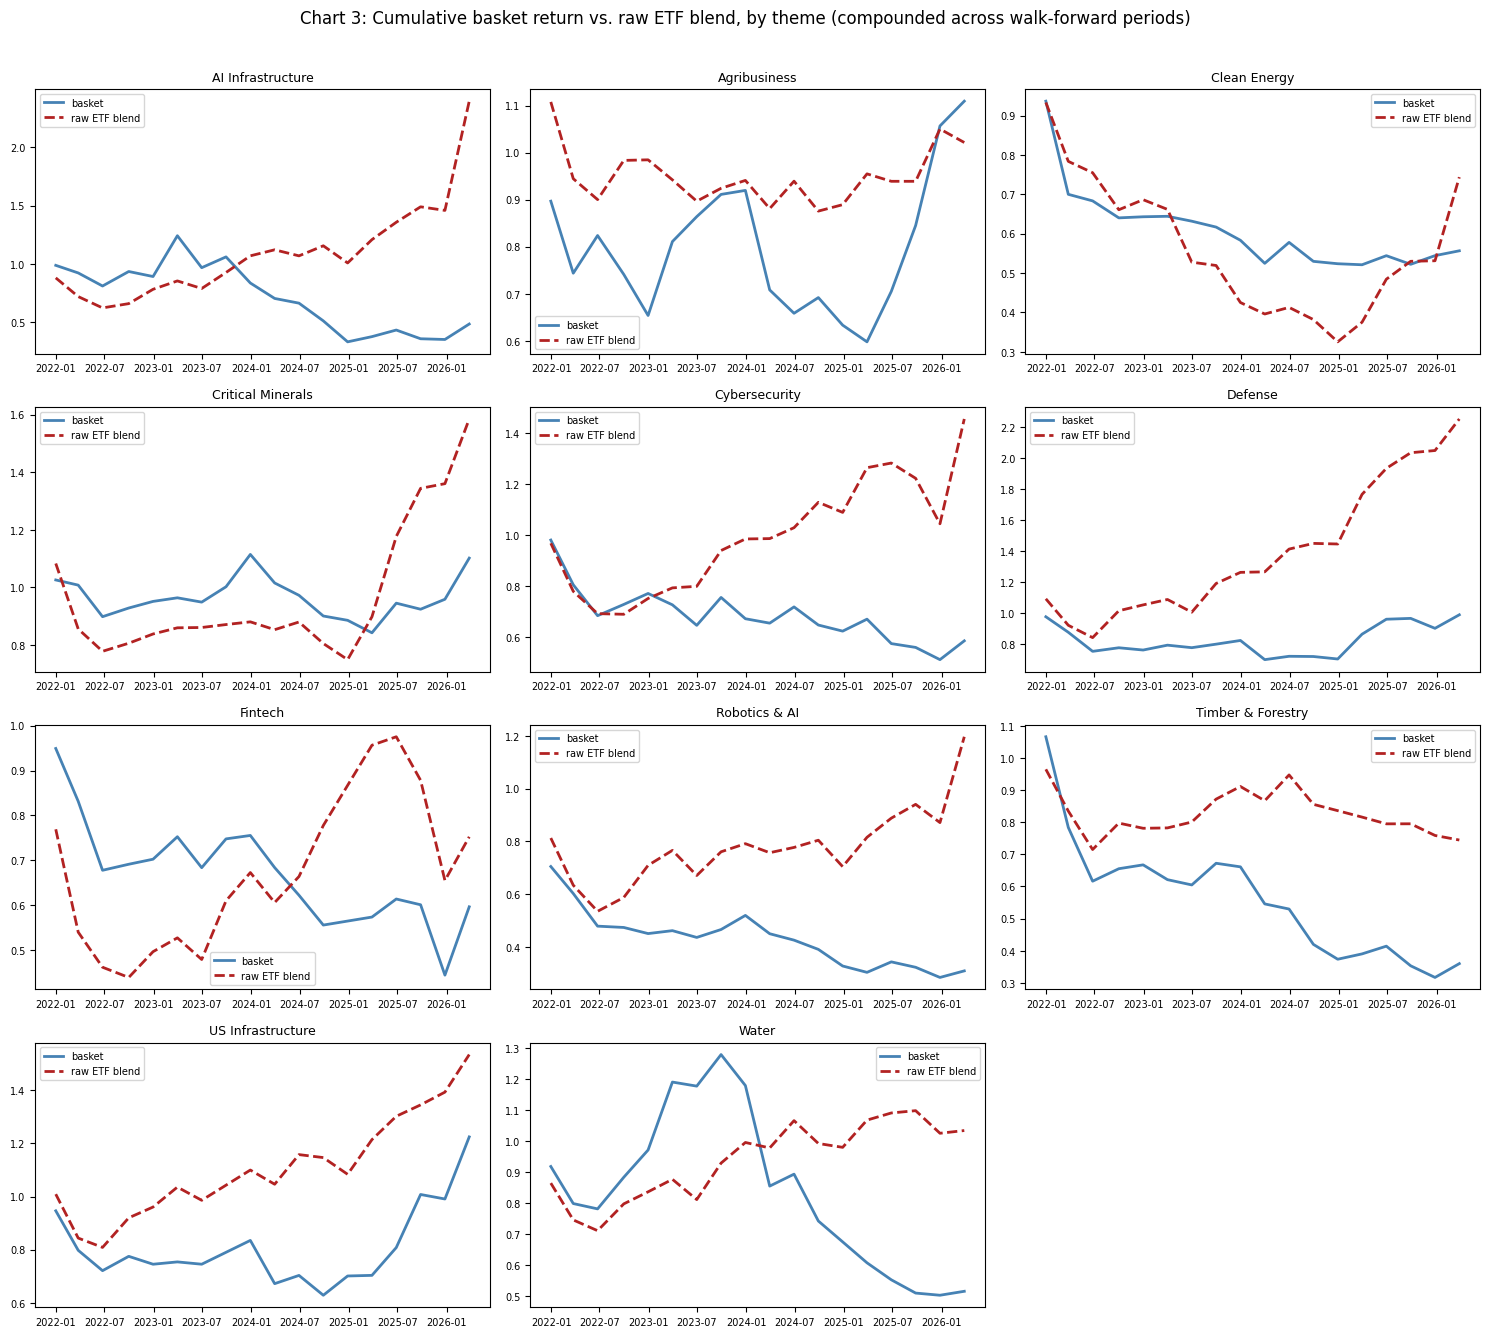

In [20]:
# -------------------- Chart 3. Cumulative basket return vs raw ETF blend --------------------
import matplotlib.pyplot as plt
import math

ev = results["evaluation"]

if "raw_etf_blend_period_return" not in ev.columns:
    print("Chart 3 needs a fresh backtest run: 'raw_etf_blend_period_return' "
          "is not in results['evaluation'] yet.\n"
          "Restart the kernel, rerun the '4. Point in time backtest' cell, then re-run this cell.")
else:
    themes = sorted(ev["theme"].unique())
    ncols = 3
    nrows = math.ceil(len(themes) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.4 * nrows))
    axes = axes.flatten()

    for ax, theme in zip(axes, themes):
        sub = ev[ev["theme"] == theme].sort_values("rebalance_date")
        b = sub["raw_basket_period_return"].fillna(0.0)
        e = sub["raw_etf_blend_period_return"].fillna(0.0)
        basket_curve = (1.0 + b).cumprod().values
        etf_curve = (1.0 + e).cumprod().values
        x = sub["rebalance_date"].values
        ax.plot(x, basket_curve, linewidth=2.0, color="steelblue", label="basket")
        ax.plot(x, etf_curve, linewidth=2.0, linestyle="--", color="firebrick",
                label="raw ETF blend")
        ax.set_title(theme, fontsize=9)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

    for ax in axes[len(themes):]:
        ax.axis("off")

    fig.suptitle("Chart 3: Cumulative basket return vs. raw ETF blend, by theme "
                 "(compounded across walk-forward periods)", fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig("outputs/fig_v3_chart3_cumulative_return.png", dpi=150)
    plt.show()

In [21]:
# -------------------- 6c. Rank matched placebo admission --------------------
# Each real rank is compared with the same rank from time shifted null themes.
results["placebo_rank_thresholds"].tail(30)


,rebalance_date,theme,rank,actual_penalized_distance,null_alpha_distance,placebo_rank_pvalue,n_placebo_ranks
2310,2026-03-27,Timber & Forestry,6,2.094109,2.725739,0.333333,2
2311,2026-03-27,Timber & Forestry,7,2.129413,2.869329,0.333333,2
2312,2026-03-27,Timber & Forestry,8,2.157665,3.080774,0.333333,2
2313,2026-03-27,Timber & Forestry,9,2.212305,3.328514,0.333333,2
2314,2026-03-27,Timber & Forestry,10,2.236162,3.378206,0.333333,2
2315,2026-03-27,Timber & Forestry,11,2.259283,3.551826,0.333333,2
2316,2026-03-27,Timber & Forestry,12,2.329723,3.616695,0.333333,2
2317,2026-03-27,Timber & Forestry,13,2.393392,3.744198,0.333333,2
2318,2026-03-27,Timber & Forestry,14,2.510496,3.860575,0.333333,2
2319,2026-03-27,Timber & Forestry,15,2.520094,4.043434,0.333333,2


## Step 7 — Independent economic relevance review

In [22]:
# -------------------- 7a. Create a blinded review sample --------------------
# Score each company from 0 to 3 using filings available before the rebalance date:
# 0 = no exposure, 1 = incidental, 2 = meaningful, 3 = central business driver.
import importlib
import src.evaluation_v3 as ev3


importlib.reload(ev3)
make_semantic_review_sample = ev3.make_semantic_review_sample

semantic_sample = make_semantic_review_sample(
    latest_scores,
    metadata=None,          # optionally pass ticker indexed sector and market cap data
    top_k=10,
    controls_per_candidate=1,
    random_state=RANDOM_STATE,
)

os.makedirs("outputs", exist_ok=True)
semantic_sample["review_sheet"].to_csv(
    "outputs/semantic_review_sheet.csv", index=False
)
semantic_sample["review_key"].to_csv(
    "outputs/semantic_review_key_PRIVATE.csv", index=False
)
semantic_sample["review_sheet"].head()

,review_id,theme,ticker,relevance_score,reviewer_notes
0,R0020,Agribusiness,BFST,NaN,
1,R0046,Clean Energy,EEX,NaN,
2,R0140,Robotics & AI,ACB,NaN,
3,R0031,Clean Energy,GOOS,NaN,
4,R0068,Cybersecurity,ASA,NaN,


In [23]:
# -------------------- 7b. Evaluate a completed review --------------------
# Run only after filling relevance_score in outputs/semantic_review_sheet.csv.
from src.evaluation_v3 import evaluate_semantic_review

completed_review = pd.read_csv("outputs/semantic_review_sheet.csv")
review_key = pd.read_csv("outputs/semantic_review_key_PRIVATE.csv")

n_completed = pd.to_numeric(
    completed_review["relevance_score"], errors="coerce"
).notna().sum()

if n_completed == 0:
    print(
        "No semantic reviews completed. "
        "Fill relevance_score before running this evaluation."
    )
else:
    semantic_results = evaluate_semantic_review(completed_review, review_key)
    display(semantic_results)


No semantic reviews completed. Fill relevance_score before running this evaluation.


## Interpretation

A credible theme should show positive forward rank correlation, a positive top versus bottom exposure spread, positive basket correlation to the residualized ETF blend, and a low placebo p value. The semantic review is a separate economic check. Raw basket return remains secondary because the objective is exposure discovery rather than replication of a large cap ETF.

In [24]:
# -------------------- 8. Export run results for review --------------------
from pathlib import Path
import zipfile

repo = Path.cwd()
outputs_dir = repo / "outputs"
outputs_dir.mkdir(exist_ok=True)

# Export the new diagnostics automatically.
results["evaluation"].to_csv(outputs_dir / "v3_forward_evaluation.csv", index=False)
results["candidate_forward_exposure"].to_csv(
    outputs_dir / "v3_candidate_forward_exposure.csv",
    index=False,
)
results["placebo_rank_thresholds"].to_csv(
    outputs_dir / "v3_placebo_rank_thresholds.csv",
    index=False,
)
results["theme_reference_distances"].to_csv(
    outputs_dir / "v3_theme_reference_distances.csv",
    index=False,
)
results["overlap_diagnostics"].to_csv(
    outputs_dir / "v3_overlap_diagnostics.csv",
    index=False,
)
results["timings"].to_csv(outputs_dir / "v3_timings.csv", index=False)
basket_history.to_csv(outputs_dir / "v3_basket_history.csv", index=False)

zip_path = repo / "ThemeCloner_V3_run_results.zip"
files_to_include = [
    repo / "ThemeCloner_V2_WalkForward_revised.ipynb",
    repo / "src" / "matching_v3.py",
    repo / "src" / "walkforward_v3.py",
    repo / "src" / "evaluation_v3.py",
]

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for file in files_to_include:
        if file.exists():
            z.write(file, file.relative_to(repo))

    for file in outputs_dir.rglob("*"):
        if file.is_file():
            z.write(file, file.relative_to(repo))

print(f"Created: {zip_path}")


Created: C:\Users\aamin\ThemeCloner2\ThemeCloner_V3_run_results.zip


In [26]:
# -------------------- 9. Git commit and push --------------------
# Save the notebook before running this cell.
import subprocess

FILES_TO_COMMIT = [
    "ThemeCloner_V2_WalkForward_revised.ipynb",
    "src/matching_v3.py",
    "src/walkforward_v3.py",
    "src/evaluation_v3.py",
]

def run_git(*args):
    result = subprocess.run(
        ["git", *args],
        cwd=ROOT,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    return result

run_git("status", "--short")
run_git("add", *FILES_TO_COMMIT)
run_git("diff", "--cached", "--stat")
run_git("commit", "-m", "Improve theme matching diagnostics and parallel placebos")
run_git("push")


 M ThemeCloner_V2_WalkForward.ipynb
 M ThemeCloner_V2_WalkForward_revised.ipynb
 M outputs/fig_v2_walkforward_equity.png
?? .ipynb_checkpoints/ThemeCloner_V2_WalkForward_revised-checkpoint.ipynb
?? IMPLEMENTATION_NOTES.md
?? ThemeCloner_V3_run_results.zip
?? outputs/fig_v3_chart1_median_etf_corr.png
?? outputs/fig_v3_chart2_tracking_through_time.png
?? outputs/fig_v3_chart3_cumulative_return.png
?? outputs/semantic_review_key_PRIVATE.csv
?? outputs/semantic_review_sheet.csv
?? outputs/v3_basket_history.csv
?? outputs/v3_candidate_forward_exposure.csv
?? outputs/v3_forward_evaluation.csv
?? outputs/v3_overlap_diagnostics.csv
?? outputs/v3_placebo_rank_thresholds.csv
?? outputs/v3_theme_reference_distances.csv
?? outputs/v3_timings.csv
?? src/ThemeCloner2_chart_cells.py
?? src/__pycache__/evaluation_v3.cpython-310.pyc
?? src/__pycache__/matching_v3.cpython-310.pyc
?? src/__pycache__/walkforward_v3.cpython-310.pyc


 ThemeCloner_V2_WalkForward_revised.ipynb | 2708 ++++++++++++++++++++++++

CompletedProcess(args=['git', 'push'], returncode=0, stdout='', stderr='To https://github.com/AA-mini/ThemeCloner2.git\n   93f1ee0..fa2d229  master -> master\n')